# Group Comparison

Flexible group-comparison notebook. Build views by genotype, line, cohort, dataset, or custom combinations, then plot RT, MT, psychometric curves, and JND insets.

## 1. Setup

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "analysis" / "daily_merge.py").exists() and (candidate / "DataFiles").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find the Mafalda_analysis repo root from the current working directory."
    )

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%load_ext autoreload
%autoreload 2

ROOT

PosixPath('/Users/mafaldavalente/Documents/Mafalda_analysis')

## 2. Choose Datasets

`DATASET_SELECTIONS` is the safest option when comparing different lines/cohorts. Set it to `None` to use all combinations of `LINES` and `COHORTS`.

In [4]:
LINES = ["CNTNAP2"]
COHORTS = ["cohort3"]

# Explicit selections can mix lines/cohorts, e.g.:
# DATASET_SELECTIONS = [("CNTNAP2", "cohort2"), ("CNTNAP2", "cohort3"), ("SHANK3", "cohort1")]
DATASET_SELECTIONS = [("CNTNAP2", "cohort2"), ("CNTNAP2", "cohort4")]

## 3. Choose Comparison

Common presets:

- Same line/cohort, compare genotypes: `COMPARISON = "genotypes"`, `SPLIT_BY = "none"`
- Same line, multiple cohorts, keep cohorts separate: `COMPARISON = "genotypes"`, `SPLIT_BY = "dataset"`
- Same line, multiple cohorts, collapse cohorts by genotype: `COMPARISON = "genotypes"`, `SPLIT_BY = "none"`
- Same genotype across lines/cohorts: `COMPARISON = "datasets"`, `GENOTYPES = ["hom"]`
- Compare experimentors within selected datasets: `COMPARISON = "experimentor"`
- Fully custom: `COMPARISON = "custom"` and edit `CUSTOM_SPECS`.

In [5]:
COMPARISON = "genotypes"  # "genotypes", "datasets", "lines", "cohorts", "experimentor", or "custom"
SPLIT_BY = "dataset"         # for COMPARISON="genotypes": "none", "dataset", "line", or "cohort"
GENOTYPES = ["wt", "het", "hom"]

CUSTOM_SPECS = [
    # {"name": "CNTNAP2 hom collapsed", "line": "CNTNAP2", "genotype": "hom"},
    # {"name": "SHANK3 hom", "line": "SHANK3", "genotype": "hom"},
    # {"name": "CNTNAP2 cohort2 hom", "dataset_key": "CNTNAP2:cohort2", "genotype": "hom"},
    # {"name": "CNTNAP2 cohort3 hom", "dataset_key": "CNTNAP2:cohort3", "genotype": "hom"},
]

## 4. Load Data And Build Views

In [6]:
from Pipeline.group_comparison import (
    build_group_views,
    build_view_style_maps,
    load_groupcomparison_data,
    summarize_views,
)

data = load_groupcomparison_data(
    lines=LINES,
    cohorts=COHORTS,
    dataset_selections=DATASET_SELECTIONS,
)
df_plot = data["df_plot"]

views = build_group_views(
    df_plot,
    comparison=COMPARISON,
    split_by=SPLIT_BY,
    genotypes=GENOTYPES,
    custom_specs=CUSTOM_SPECS,
)

print("Loaded datasets:", data["selections"])
print("Usable dataset keys:", data["usable_dataset_names"])
view_summary = summarize_views(df_plot, views)
display(view_summary)

view_colors, view_styles = build_view_style_maps(df_plot, views)
print("View colors:", view_colors)
print("View styles:", view_styles)


Loaded datasets: [('CNTNAP2', 'cohort2'), ('CNTNAP2', 'cohort4')]
Usable dataset keys: ['CNTNAP2:cohort2', 'CNTNAP2:cohort4']


,view,rows,animals,lines,cohorts,genotypes
0,wt CNTNAP2:cohort2,304293,5,CNTNAP2,cohort2,wt
1,wt CNTNAP2:cohort4,53133,4,CNTNAP2,cohort4,wt
2,het CNTNAP2:cohort2,290755,5,CNTNAP2,cohort2,het
3,het CNTNAP2:cohort4,103644,9,CNTNAP2,cohort4,het
4,hom CNTNAP2:cohort2,276785,6,CNTNAP2,cohort2,hom
5,hom CNTNAP2:cohort4,88327,6,CNTNAP2,cohort4,hom


View colors: {'wt CNTNAP2:cohort2': '#4D4D4D', 'wt CNTNAP2:cohort4': '#4D4D4D', 'het CNTNAP2:cohort2': '#7A8F28', 'het CNTNAP2:cohort4': '#7A8F28', 'hom CNTNAP2:cohort2': '#C24A7A', 'hom CNTNAP2:cohort4': '#C24A7A'}
View styles: {'wt CNTNAP2:cohort2': {'linestyle': '-', 'marker': 'o', 'markerfacecolor': None}, 'wt CNTNAP2:cohort4': {'linestyle': '--', 'marker': 'o', 'markerfacecolor': 'white'}, 'het CNTNAP2:cohort2': {'linestyle': '-', 'marker': 'o', 'markerfacecolor': None}, 'het CNTNAP2:cohort4': {'linestyle': '--', 'marker': 'o', 'markerfacecolor': 'white'}, 'hom CNTNAP2:cohort2': {'linestyle': '-', 'marker': 'o', 'markerfacecolor': None}, 'hom CNTNAP2:cohort4': {'linestyle': '--', 'marker': 'o', 'markerfacecolor': 'white'}}


## 5. Prepare Once

This is the expensive step. Rerun it if you change filters, views, datasets, or overlay settings. You do not need to rerun it just to change `LAYOUT` below.

In [7]:
import importlib
import GroupComparison.config as gconfig
import GroupComparison.plots as gplots
import Pipeline.group_comparison as gc

LOAD_OVERLAYS = True

importlib.reload(gconfig)
importlib.reload(gplots)
importlib.reload(gc)

cfg = gconfig.GroupComparisonConfig(
    error_mode="individuals",
    skip_psy_fits=(50,),
    psychometric_aggregation="animal_trials",
    summary_abort_types=("Fixation", "MT+", "RT-"),
    ild_shift_for_abl50=True,
)

fcfg = gconfig.FilterConfig(
    training_min=16,
    session_min=0,
    drop_repeat_trials=True,
    session_type_values=[1],
    stim_dur_values=[6000],
    sessiontype_or_stimdur="or",
)
style = gconfig.PlotStyle(title_fs=24, label_fs=25, tick_fs=24, legend_fs=16)

bundle = gc.prepare_flexible_groupcomparison(
    df=df_plot,
    views=views,
    load_overlays=LOAD_OVERLAYS,
    cfg=cfg,
    fcfg=fcfg,
    style=style,
    view_colors=view_colors,
    view_styles=view_styles,
)

print("Filtered rows:", len(bundle["df_filtered"]))
print("Prepared views:", list(bundle["prepared"].keys()))

   ABL       JND
0   20  2.520922
1   40  2.375468
2   60  2.596303
   ABL       JND
0   20  1.973498
1   40  2.205691
2   60  2.117981
   ABL       JND
0   20  2.417991
1   40  2.662042
2   60  3.408058
   ABL       JND
0   20  2.440373
1   40  2.476703
2   60  2.729276
   ABL       JND
0   20  2.830306
1   40  3.149114
2   60  2.634753
   ABL       JND
0   20  2.243291
1   40  2.369473
2   60  2.447866
   ABL       JND
0   20  2.837397
1   40  2.431335
2   60  2.800656
   ABL       JND
0   20  2.834542
1   40  2.917051
2   60  3.423825
   ABL       JND
0   20  2.662742
1   40  3.109566
2   60  2.755908
   ABL       JND
0   20  2.216937
1   40  2.419734
2   60  2.824892
   ABL       JND
0   20  2.242021
1   40  2.705318
2   60  3.080025
   ABL       JND
0   20  2.473312
1   40  2.428629
2   60  3.426389
   ABL       JND
0   20  2.170783
1   40  2.557391
2   60  4.315064
   ABL       JND
0   20  2.268323
1   40  2.587697
2   60  3.595959
   ABL       JND
0   20  2.500051
1   40  3.3338

## 6. Plot From Prepared Data

`LAYOUT = "abls_4x3"` is usually best for direct comparison between views. `LAYOUT = "views_3x3"` gives one row per view.
`LAYOUT = "animals_plus_mean"` makes one panel per animal plus a final average panel for the selected view.

You can also adjust the axis-limit variables in the next cell and rerun just that cell without recomputing preparation.

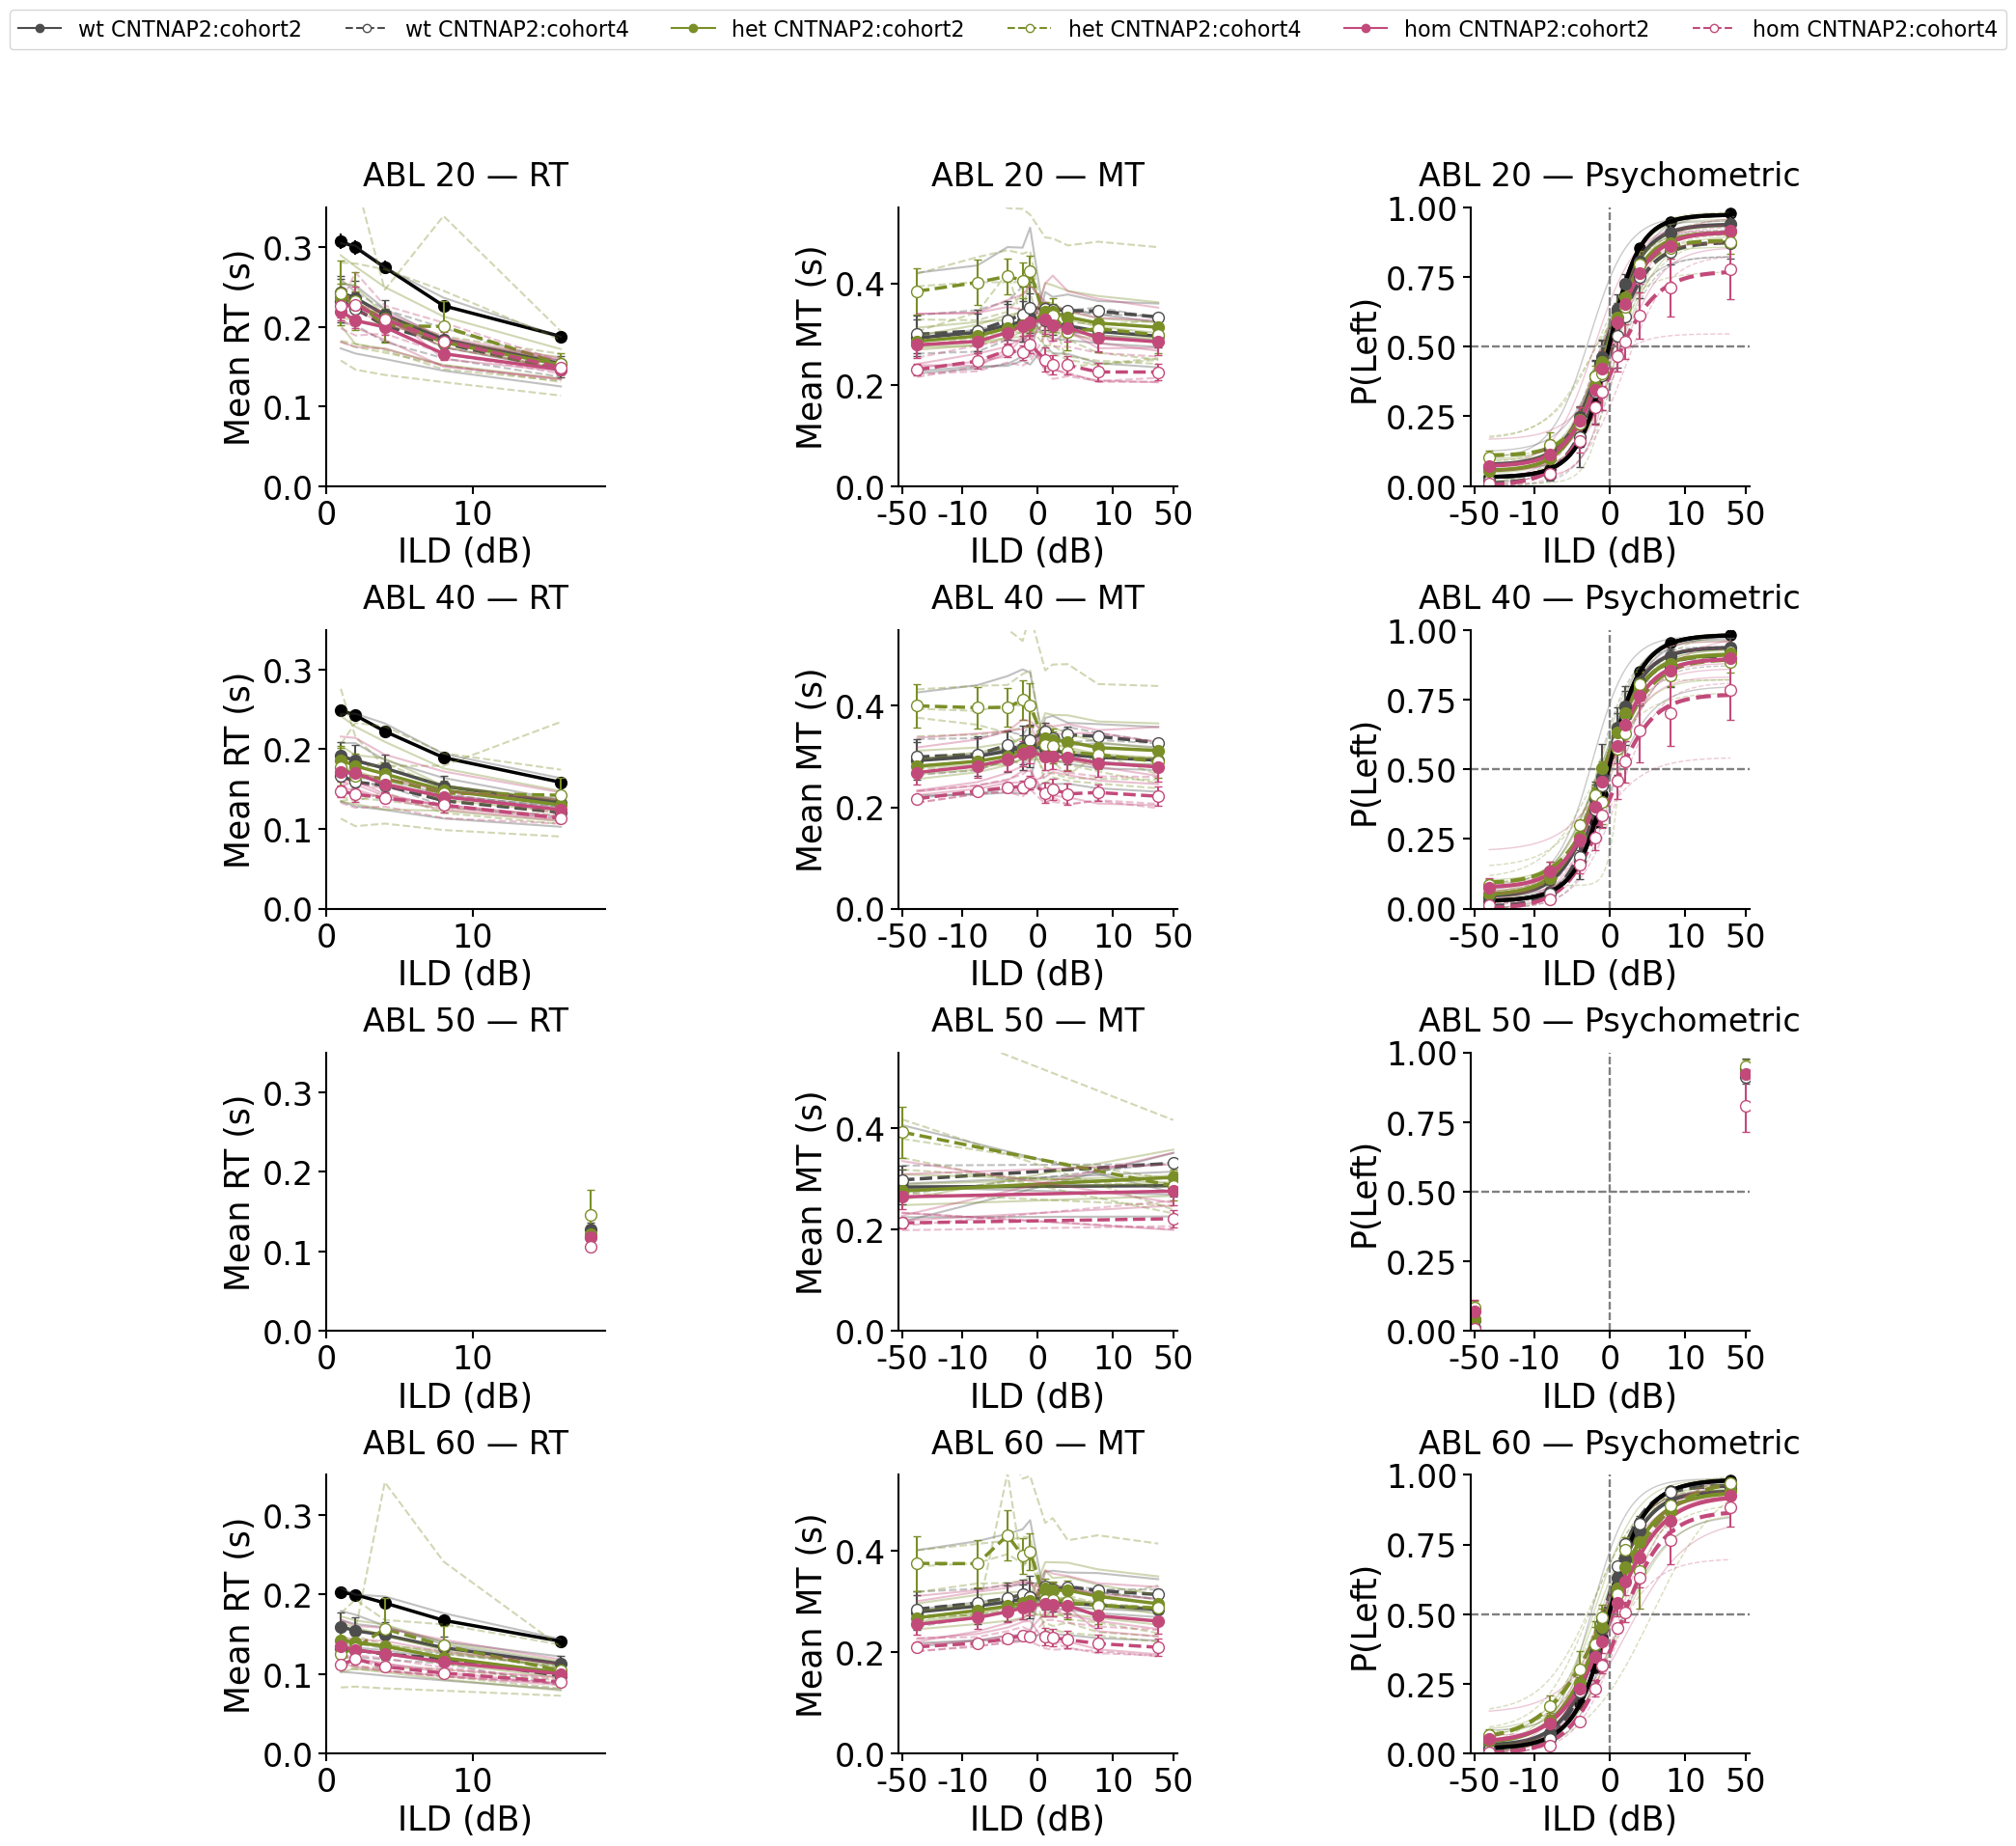

{'main': <Figure size 1800x1920 with 12 Axes>}

In [8]:
from dataclasses import replace

LAYOUT = "abls_4x3"  # "abls_4x3", "views_3x3", "animals_plus_mean", or "psy_params"
PLOT_VIEW = None  # set to a view name to plot just one group for animals_plus_mean

# Change these and rerun only this cell when you want a different view window.
XLIM_ABS = bundle["cfg"].xlim_abs
XLIM_SYM = bundle["cfg"].xlim_sym
YLIM_RT = bundle["cfg"].ylim_rt
YLIM_MT = bundle["cfg"].ylim_mt

plot_cfg = replace(
    bundle["cfg"],
    xlim_abs=XLIM_ABS,
    xlim_sym=XLIM_SYM,
    ylim_rt=YLIM_RT,
    ylim_mt=YLIM_MT,
)

plot_views = [v for v in views if PLOT_VIEW is None or v.name == PLOT_VIEW]
if not plot_views:
    raise ValueError(f"PLOT_VIEW={PLOT_VIEW!r} did not match any selected view.")

out = gc.plot_flexible_groupcomparison(
    bundle=bundle,
    views=plot_views,
    layout=LAYOUT,
    cfg=plot_cfg,
    show=True,
)

out["figures"]

## 7. Summary Metrics and Parameters

/Users/mafaldavalente/Documents/Mafalda_analysis/GroupComparison/plots.py:1290: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.12, 1, 0.95])


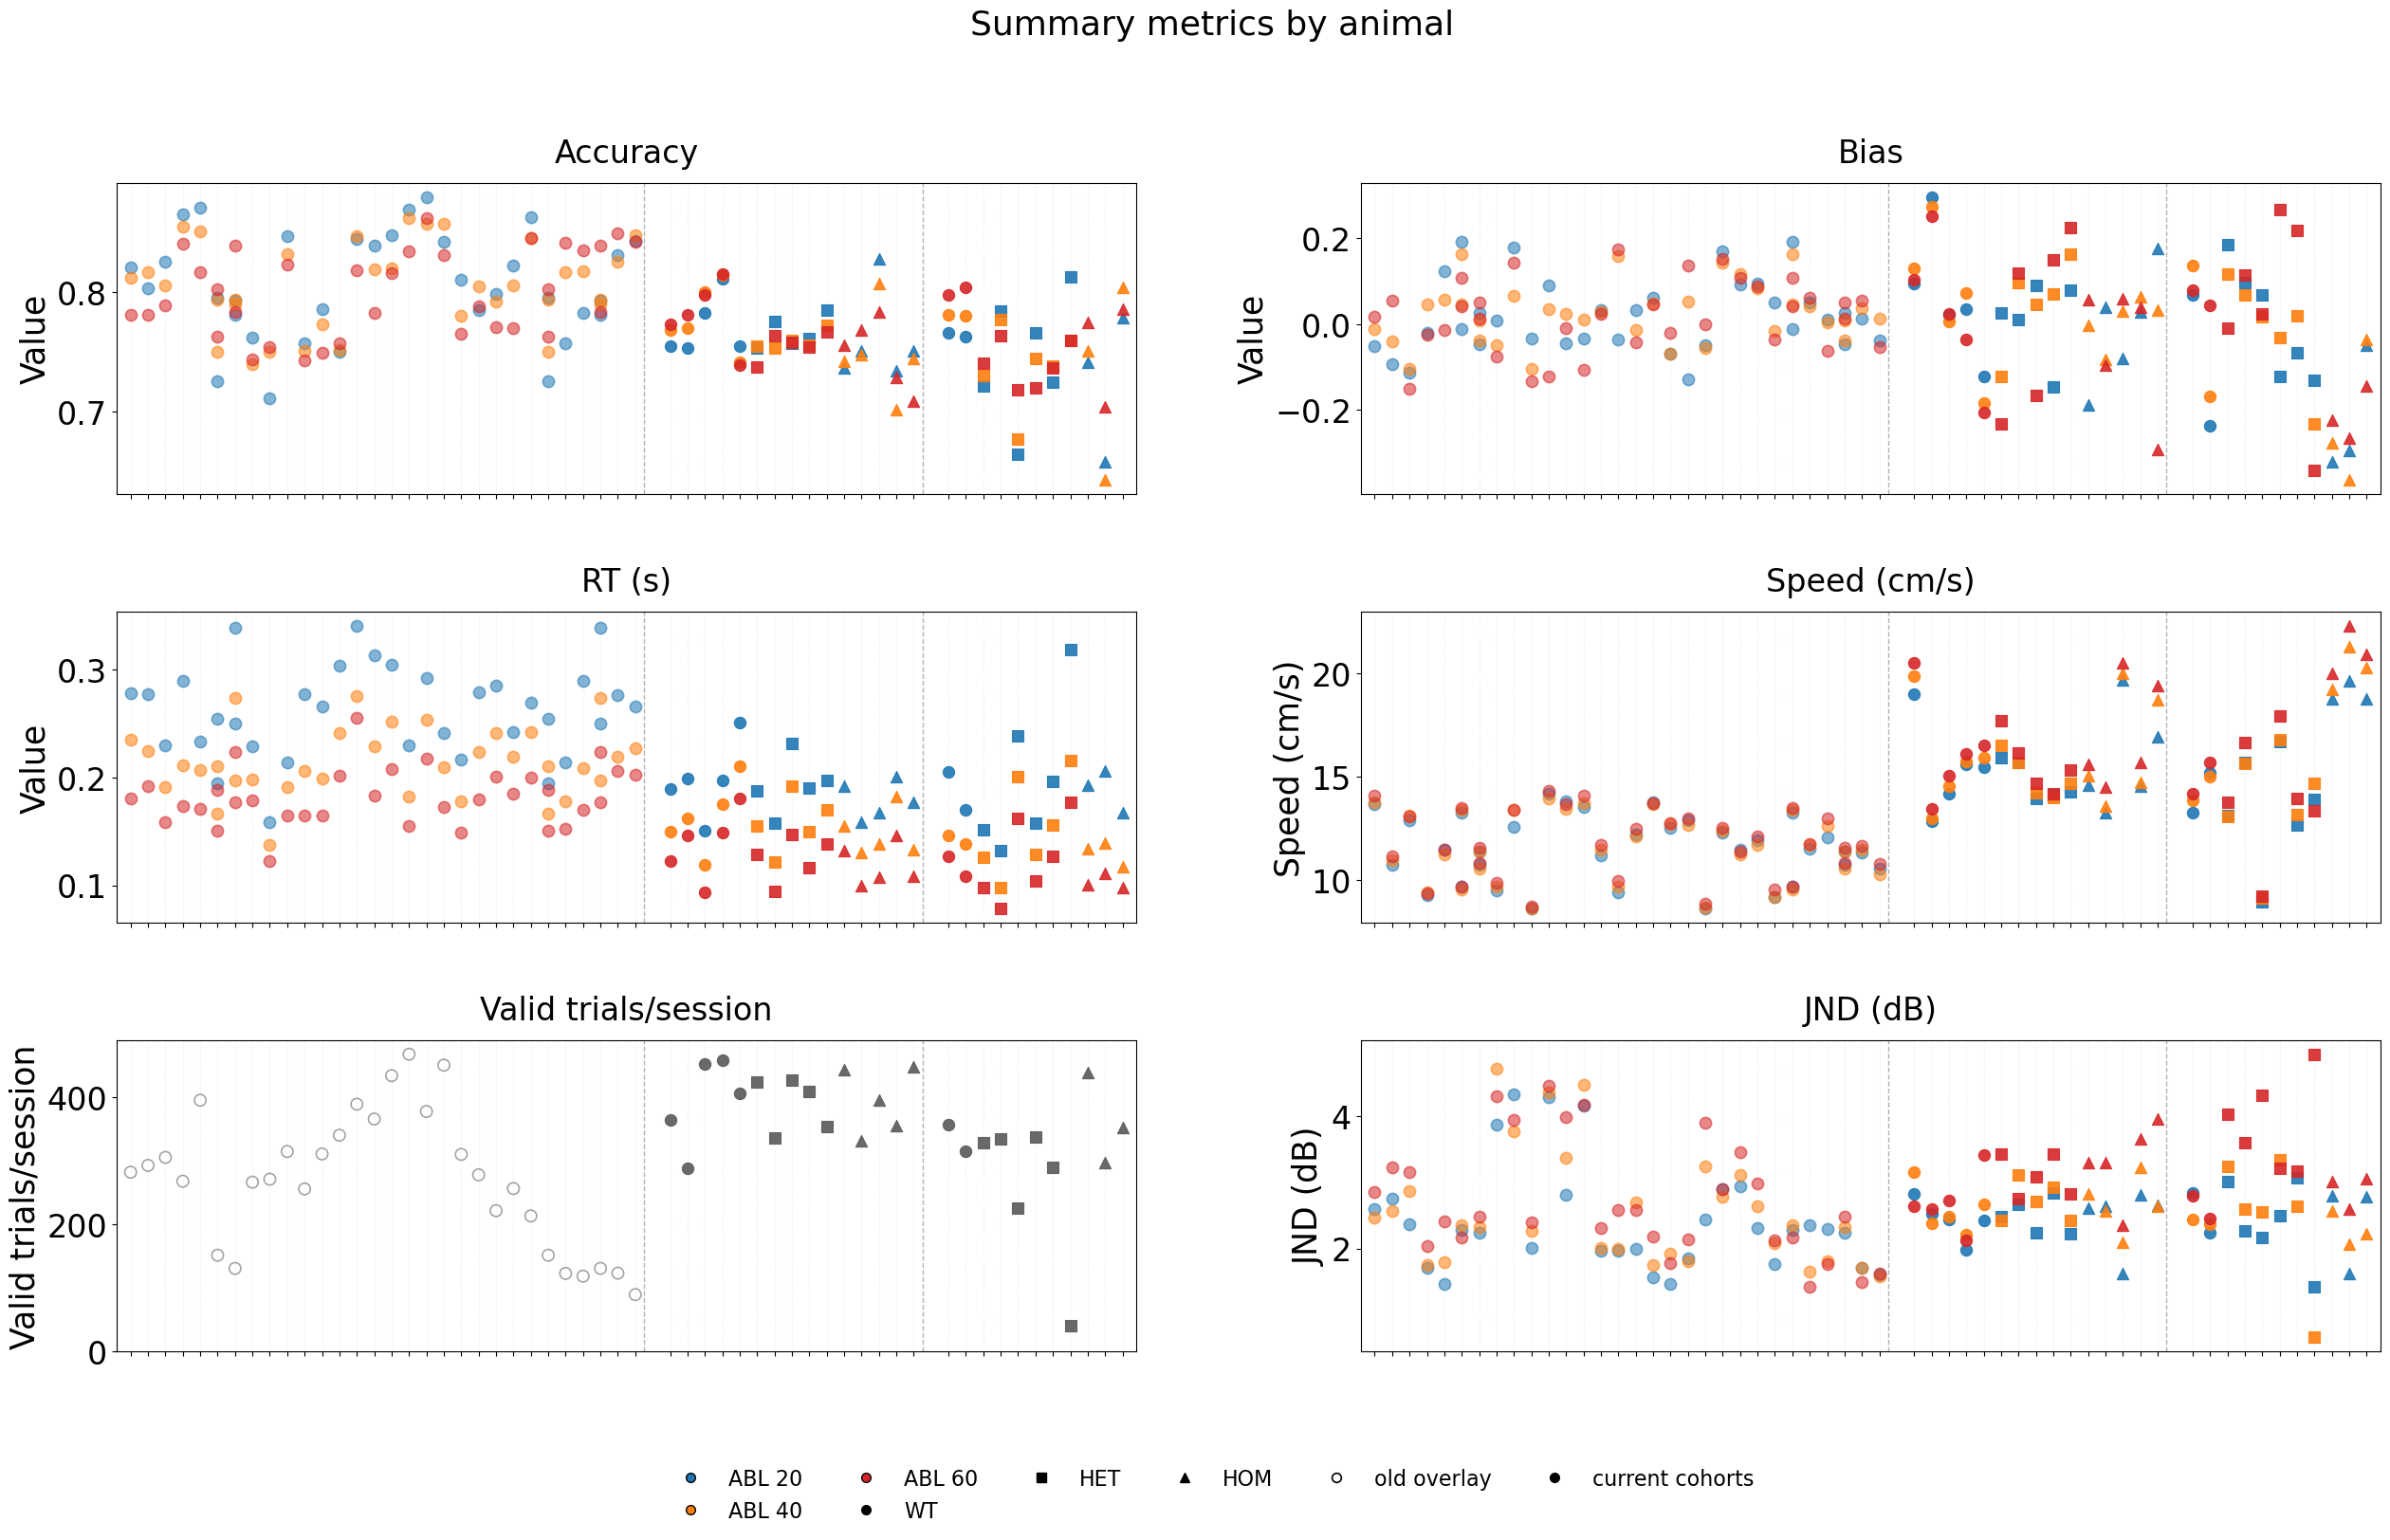

{'summary_metrics': <Figure size 3080x1600 with 6 Axes>}

In [9]:
LAYOUT = "summary_metrics"  # or "psy_params" or "summary_aborts" "summary_metrics"
PLOT_VIEW = None

# Reuse the bundle prepared in the cell above.
plot_views = [v for v in views if PLOT_VIEW is None or v.name == PLOT_VIEW]
if not plot_views:
    raise ValueError(f"PLOT_VIEW={PLOT_VIEW!r} did not match any selected view.")

out = gc.plot_flexible_groupcomparison(
    bundle=bundle,
    views=plot_views,
    layout=LAYOUT,
    show=True,
)

out["figures"]

## 8. Example Recipes

### Compare genotypes within one cohort

```python
DATASET_SELECTIONS = [("CNTNAP2", "cohort3")]
COMPARISON = "genotypes"
SPLIT_BY = "none"
GENOTYPES = ["wt", "het", "hom"]
```

### Compare genotypes and keep cohorts separate

```python
DATASET_SELECTIONS = [("CNTNAP2", "cohort2"), ("CNTNAP2", "cohort3")]
COMPARISON = "genotypes"
SPLIT_BY = "dataset"
```

### Collapse cohorts and compare genotypes

```python
DATASET_SELECTIONS = [("CNTNAP2", "cohort2"), ("CNTNAP2", "cohort3")]
COMPARISON = "genotypes"
SPLIT_BY = "none"
```

### Compare the same genotype across datasets

```python
DATASET_SELECTIONS = [("CNTNAP2", "cohort2"), ("CNTNAP2", "cohort3"), ("SHANK3", "cohort1")]
COMPARISON = "datasets"
GENOTYPES = ["hom"]
```

### Custom comparison

```python
COMPARISON = "custom"
CUSTOM_SPECS = [
    {"name": "CNTNAP2 hom all cohorts", "line": "CNTNAP2", "genotype": "hom"},
    {"name": "SHANK3 hom", "line": "SHANK3", "genotype": "hom"},
]
```

## 9. Optional Save For Google Slides

In [ ]:
SAVE_FIGURES = False

def _save_figures(figures, out_dir, prefix):
    for name, fig in figures.items():
        if isinstance(fig, dict):
            subdir = out_dir / name
            subdir.mkdir(parents=True, exist_ok=True)
            _save_figures(fig, subdir, prefix)
        else:
            fig.savefig(out_dir / f"{prefix}_{name}.png", dpi=250, bbox_inches="tight")

if SAVE_FIGURES:
    out_dir = ROOT / "outputs" / "group_comparison"
    out_dir.mkdir(parents=True, exist_ok=True)
    _save_figures(out["figures"], out_dir, f"group_comparison_{LAYOUT}")
    print(out_dir)